# Clearing-tier analysis — capital ratios, margin calls, balance sheets

Reads `output/clearing_{regime}.csv` — one row per clearing member per 60-tick variation-margin cycle (D29; ODD §Step Sequence step 11). Capital adequacy is ODD-faithful: with ODD-scale CM capital (`U[5B,10B]`) the ratio sits far above the 8% Basel floor in the calm regime; the margin cycle is exercised but the floor binds only under stress (ODD `MarginCallClustering`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REGIME = "calm"   # "calm" or "stressed"
df = pd.read_csv(f"output/clearing_{REGIME}.csv")
df["agent"] = df["kind"] + "-" + df["agent_id"].astype(str)
print(f"{REGIME}: {df.t.nunique()} margin cycles × {df.agent_id.nunique()} clearing members "
      f"= {len(df)} rows")
df.head()

calm: 6 margin cycles × 15 clearing members = 90 rows


,t,agent_id,kind,cash,own_position,client_notional,capital_ratio,initial_margin,maintenance_margin,vm_cycle,vm_cumulative,call_indicator,has_defaulted,agent
0,59,10,BCM,8.790439e+09,29,0.0,122732.496205,14324.55,13608.3225,192.125,192.125,False,False,BCM-10
1,59,11,BCM,9.853490e+09,16,0.0,249354.444478,7903.20,7508.0400,106.000,106.000,False,False,BCM-11
2,59,12,BCM,8.891918e+09,21,0.0,171444.335980,10372.95,9854.3025,139.125,139.125,False,False,BCM-12
3,59,13,BCM,7.333605e+09,48,0.0,61861.906879,23709.60,22524.1200,318.000,318.000,False,False,BCM-13
4,59,14,BCM,5.771448e+09,68,0.0,34365.516341,33588.60,31909.1700,450.500,450.500,False,False,BCM-14


## Final-cycle balance sheets

Per-CM snapshot at the last margin cycle. `cash` is the CM's capital under futures-margin accounting (D29: entry posts IM, no notional paid; cash = starting capital + cumulative variation margin). NBCM `client_notional` is 0 while client books are inert (no trade novation yet).

In [2]:
last = df[df.t == df.t.max()].set_index("agent")
cols = ["kind", "cash", "own_position", "client_notional", "capital_ratio",
        "initial_margin", "maintenance_margin", "vm_cumulative", "has_defaulted"]
last[cols].round(2)

,kind,cash,own_position,client_notional,capital_ratio,initial_margin,maintenance_margin,vm_cumulative,has_defaulted
agent,,,,,,,,,
BCM-10,BCM,8.790439e+09,-270,0.0,13246.74,132718.50,126082.58,543.00,False
BCM-11,BCM,9.853490e+09,212,0.0,18911.09,104208.60,98998.17,304.75,False
BCM-12,BCM,8.891918e+09,-21,0.0,172281.43,10322.55,9806.42,874.62,False
BCM-13,BCM,7.333604e+09,363,0.0,8220.02,178432.65,169511.02,-846.00,False
BCM-14,BCM,5.771446e+09,477,0.0,4922.99,234469.35,222745.88,-1638.62,False
BCM-15,BCM,8.723812e+09,-163,0.0,21776.14,80122.65,76116.52,1219.38,False
BCM-16,BCM,6.629128e+09,-318,0.0,8481.87,156312.90,148497.25,888.50,False
BCM-17,BCM,7.347778e+09,452,0.0,6614.24,222180.60,211071.57,-1549.75,False
BCM-18,BCM,5.649609e+09,-386,0.0,5955.16,189738.30,180251.38,1382.12,False


## Capital-ratio paths

`capital_ratio = cash / exposure notional` (ODD §Mech #2). NBCM ratios are `inf` while client books are inert — only the BCM own-account ratios are finite. Log scale; the red line is the 8% floor.

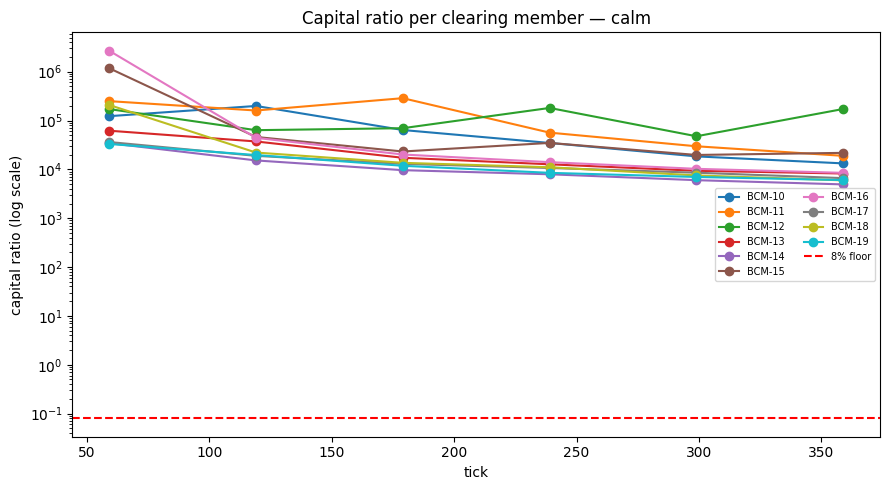

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
for agent, g in df.groupby("agent"):
    cr = g.capital_ratio.replace([np.inf, -np.inf], np.nan)
    if cr.notna().any():
        ax.plot(g.t, cr, marker="o", label=agent)
ax.axhline(0.08, ls="--", c="red", label="8% floor")
ax.set_yscale("log")
ax.set_xlabel("tick"); ax.set_ylabel("capital ratio (log scale)")
ax.set_title(f"Capital ratio per clearing member — {REGIME}")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

## Variation margin & own position

Cumulative VM is each CM's settled mark-to-market PnL — the cash-depletion channel that drives the capital ratio. Own position: BCMs trade their own account FT-style; NBCMs hold none.

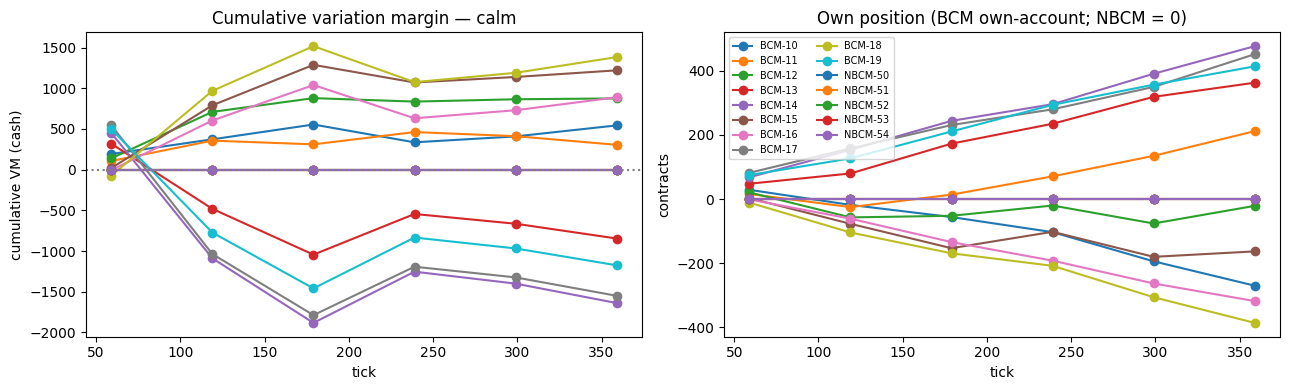

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for agent, g in df.groupby("agent"):
    axes[0].plot(g.t, g.vm_cumulative, marker="o", label=agent)
    axes[1].plot(g.t, g.own_position, marker="o", label=agent)
axes[0].axhline(0, ls=":", c="grey")
axes[0].set_title(f"Cumulative variation margin — {REGIME}")
axes[0].set_xlabel("tick"); axes[0].set_ylabel("cumulative VM (cash)")
axes[1].set_title("Own position (BCM own-account; NBCM = 0)")
axes[1].set_xlabel("tick"); axes[1].set_ylabel("contracts")
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

## Margin calls & defaults

A margin call is flagged when a cycle's `|VM| > (1 - mmPercent) × IM` — 5% of initial margin (ODD §Mech #3). The ODD pattern `MarginCallClustering` predicts these cluster in high-volatility hours, so the calm regime should show few or none.

In [5]:
calls = df.groupby("agent").call_indicator.sum().astype(int)
total = int(df.call_indicator.sum())
print(f"margin calls this run ({REGIME}): {total} total")
if total:
    print(calls[calls > 0])
else:
    print("  none — calm VM moves are small vs IM; calls cluster under stress")
n_def = int(df.has_defaulted.any())
print(f"\nCMs flagged defaulted (cash ≤ 0): {df[df.has_defaulted].agent.nunique()} "
      f"({'see waterfall stage' if n_def else 'none'})")

margin calls this run (calm): 0 total
  none — calm VM moves are small vs IM; calls cluster under stress

CMs flagged defaulted (cash ≤ 0): 0 (none)
